In [17]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits

%matplotlib notebook
nant = 30
idx = 0
products = []
revproducts = {}
auto_products = []
cross_products = []
for a1 in range(1, nant+1):
    for a2 in range(a1, nant+1):
        products.append((a1,a2))
        revproducts[(a1,a2)] = idx
        if a1 == a2:
            auto_products.append(idx)
        else:
            cross_products.append(idx)
            
        idx += 1
              
products = np.array(products, dtype=[('a1',np.int16), ('a2', np.int16)])

In [2]:
ls data/SB41379

0407_a112_k16_spi32_ps_b0_b07_c02+f1.fits
0407_a112_k16_spi32_ps_b0_b07_c02+f1.npy
0407_a112_k16_spi32_ps_b0_b07_c02+f2.fits
0407_a112_k16_spi32_ps_b0_b07_c02+f2.npy
0407_a112_k16_spi32_ps_b0_b07_c02+f3.fits
0407_a112_k16_spi32_ps_b0_b07_c02+f3.npy
0407_a112_k16_spi32_ps_b0_b07_c02+f4.fits
0407_a112_k16_spi32_ps_b0_b07_c02+f4.npy
0407_a112_k16_spi32_ps_b0_b07_c02+f5.fits
0407_a112_k16_spi32_ps_b0_b07_c02+f5.npy
0407_a112_k16_spi32_ps_b0_b07_c02+f6.fits
0407_a112_k16_spi32_ps_b0_b07_c02+f6.npy
0407_a112_k16_spi32_ps_b0_b07_c12+f1.fits
0407_a112_k16_spi32_ps_b0_b07_c12+f1.npy
0407_a112_k16_spi32_ps_b0_b07_c12+f2.fits
0407_a112_k16_spi32_ps_b0_b07_c12+f2.npy
0407_a112_k16_spi32_ps_b0_b07_c12+f3.fits
0407_a112_k16_spi32_ps_b0_b07_c12+f3.npy
0407_a112_k16_spi32_ps_b0_b07_c12+f4.fits
0407_a112_k16_spi32_ps_b0_b07_c12+f4.npy
0407_a112_k16_spi32_ps_b0_b07_c12+f5.fits
0407_a112_k16_spi32_ps_b0_b07_c12+f5.npy
0407_a112_k16_spi32_ps_b0_b07_c12+f6.fits
0407_a112_k16_spi32_ps_b0_b07_c12+f6.npy
0407

In [4]:
p = CardcapFile('data/SB41379/0407_a112_k16_spi32_ps_ball_b07_c02+f1.fits')

In [5]:
pkts = p.load_packets()

In [7]:
pkts.shape

(460800,)

In [9]:
pkts.dtype

dtype([('frame_id', '<u8'), ('bat', '<u8'), ('beam_number', 'u1'), ('sample_number', 'u1'), ('channel_number', 'u1'), ('fpga_id', 'u1'), ('nprod', '<u2'), ('flags', 'u1'), ('zero1', 'u1'), ('version', '<u4'), ('zero3', '<u4'), ('data', '<i2', (2, 465, 1, 2))])

<IPython.core.display.Javascript object>


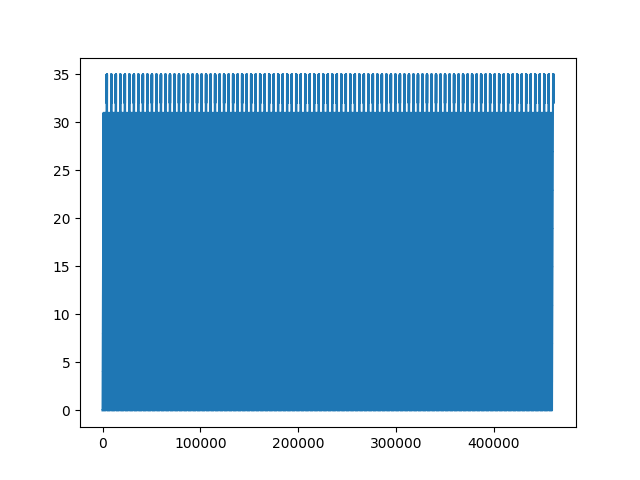

In [10]:
figure()
plot(pkts['beam_number'])

In [21]:
dbd = []
for b in range(36):
    dbd.append(pkts['data'][pkts['beam_number'] == b])
    
dbd = np.array(dbd)
dbd.shape

(36, 12800, 2, 465, 1, 2)

In [22]:
dbd = dbd.reshape(36,100, 4, 64, 465, 2)
dbd.shape

(36, 100, 4, 64, 465, 2)

In [23]:
dbd = dbd.transpose([0,1,3,2,4,5])
dbd.shape

(36, 100, 64, 4, 465, 2)

In [34]:
dbda = abs(dbd[:,:,:,0,cross_products,:].mean(axis=3))
dbda.shape

(36, 100, 64, 2)

<IPython.core.display.Javascript object>


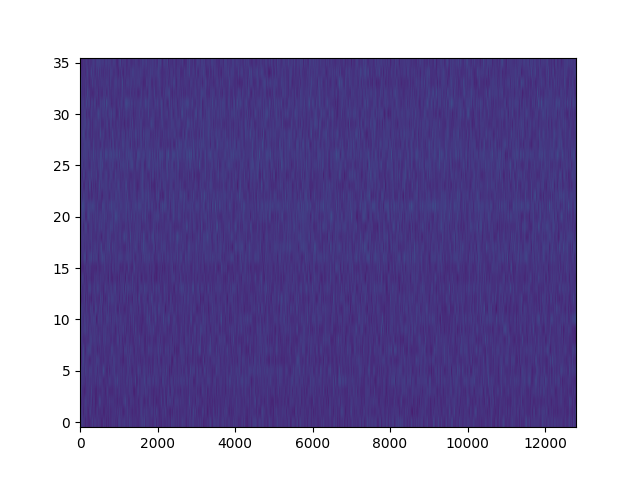

In [39]:
dbdab = dbda.reshape(36,-1).astype(float)
#dbdab -= dbdab.mean(axis=1).reshape(36,1)
figure()
imshow(dbdab[:,1:], aspect='auto', origin='lower')

<IPython.core.display.Javascript object>


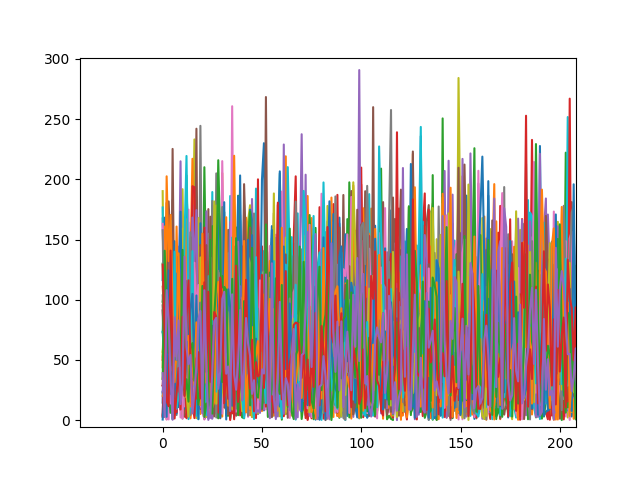

In [40]:
figure()
_ = plot(dbdab.T[:,1:])